# H2 — Decision Quality
## Adapted for seasonal aggregated data (Wyscout / `wyscout_sample.csv`)

**Original hypothesis.** Evaluates decision-making quality on pass events using StatsBomb 360° freeze frames: for every pass, calculates completion probability ($xPass$) and expected possession value ($xEPV$) for each visible candidate teammate. From this, computes **Regret** (difference between chosen pass and best possible pass) to quantify decision quality under pressure.

### Why this is an adaptation, not a recreation

In aggregated seasonal data (`wyscout_sample.csv`), there are no individual events, no alternative teammate options, and no freeze-frame geometries. We cannot know which pass options were visible. Instead, this notebook builds a **Decision Quality Index (DQI) proxy** based on technical and executive decision-making metrics per 90 within each macro role.

## Section 0 — Setup

In [1]:
%matplotlib inline
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from IPython.display import display

pd.set_option("display.max_columns", 12)

def _find_data_path() -> Path:
    env_path = os.getenv('DATA_PATH')
    if env_path and Path(env_path).exists():
        return Path(env_path)
    cur = Path.cwd()
    for _ in range(6):
        for candidate in [
            cur / "webapp" / "backend" / "data" / "wyscout_sample.csv",
            cur / "data" / "wyscout_sample.csv",
        ]:
            if candidate.exists():
                return candidate
        if cur.parent == cur:
            break
        cur = cur.parent
    candidates = [
        Path('../../webapp/backend/data/wyscout_sample.csv'),
        Path('../webapp/backend/data/wyscout_sample.csv'),
        Path('webapp/backend/data/wyscout_sample.csv'),
        Path('../../data/wyscout_sample.csv'),
        Path('../data/wyscout_sample.csv'),
        Path('data/wyscout_sample.csv'),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError("Could not locate wyscout_sample.csv. Please set DATA_PATH environment variable.")

DATA_PATH = _find_data_path()
MIN_MINUTES = 300

df = pd.read_csv(DATA_PATH, low_memory=False)
df.columns = [str(c).strip() for c in df.columns]

MACRO_MAP = {
    "GK": "GK", "CB": "CB", "LCB": "CB", "RCB": "CB",
    "LB": "FB", "RB": "FB", "LWB": "FB", "RWB": "FB",
    "DMF": "MID", "LDMF": "MID", "RDMF": "MID", "CMF": "MID", "LCMF": "MID", "RCMF": "MID",
    "AMF": "CAM",
    "LAMF": "WIDE", "RAMF": "WIDE", "LW": "WIDE", "RW": "WIDE", "LWF": "WIDE", "RWF": "WIDE",
    "CF": "FW", "SS": "FW",
}
MACRO_LABEL_EN = {"CB": "Center Back", "FB": "Full Back", "MID": "Midfielder",
                   "CAM": "Attacking Midfielder", "WIDE": "Winger", "FW": "Forward"}
ROLE_ORDER = ["CB", "FB", "MID", "CAM", "WIDE", "FW"]
ROLE_COLORS = {"CB": "#1f77b4", "FB": "#ff7f0e", "MID": "#2ca02c",
               "CAM": "#9467bd", "WIDE": "#d62728", "FW": "#8c564b"}

df["primary_position"] = df["Position"].apply(lambda p: str(p).split(",")[0].strip())
df["macro_pos"] = df["primary_position"].map(MACRO_MAP).fillna("MID")
df["minutes"] = df["Minutes played"]

out = df[(df["macro_pos"] != "GK") & (df["minutes"] >= MIN_MINUTES)].copy()
print(f"Pool: {len(out)} outfield players (>= {MIN_MINUTES} min)")
print(out["macro_pos"].value_counts().reindex(ROLE_ORDER))


Pool: 1059 outfield players (>= 300 min)


C:\Users\Dakkarm\AppData\Local\Temp\ipykernel_21616\3335120671.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["primary_position"] = df["Position"].apply(lambda p: str(p).split(",")[0].strip())
C:\Users\Dakkarm\AppData\Local\Temp\ipykernel_21616\3335120671.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["macro_pos"] = df["primary_position"].map(MACRO_MAP).fillna("MID")
C:\Users\Dakkarm\AppData\Local\Temp\ipykernel_21616\3335120671.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the res

## Section 1 — The Four Axes and Composite Index

In [2]:
if "incisive_actions90" not in out.columns:
    out["incisive_actions90"] = (
        out["Key passes/90"].fillna(0)
        + out["Passes to final third/90"].fillna(0)
        + out["Through passes/90"].fillna(0)
    )

DQ_AXES = {
    "possession_accuracy": "Accurate passes, %",
    "duel_robustness":     "Duels won, %",
    "risk_readings90":     "incisive_actions90",
    "risk_accuracy":       "Accurate progressive passes, %",
}
DQ_LABEL_EN = {
    "possession_accuracy": "Possession Accuracy",
    "duel_robustness":     "Duel Robustness",
    "risk_readings90":     "Risk Readings /90",
    "risk_accuracy":       "Risk Accuracy",
}

new_cols = {}
for k, col in DQ_AXES.items():
    new_cols[f"pct__{k}"] = out.groupby("macro_pos")[col].rank(pct=True) * 100

new_cols["pct__xg90"] = out.groupby("macro_pos")["Expected goals/90"].rank(pct=True) * 100
new_cols["pct__xa90"] = out.groupby("macro_pos")["Expected assists/90"].rank(pct=True) * 100

for k, v in new_cols.items():
    out[k] = v

out["DQI"] = out[[f"pct__{k}" for k in DQ_AXES]].mean(axis=1)
out["value_impact"] = out[["pct__xg90", "pct__xa90"]].mean(axis=1)

out = out.copy()
out["DQI"].describe().round(1)


count    1059.0
mean       50.3
std        16.2
min         5.9
25%        39.3
50%        50.4
75%        61.3
max        95.9
Name: DQI, dtype: float64

## Section 2 — DQI Correlates with Value Impact, But Is Not the Same Thing

Spearman rho (DQI vs Value Impact) = 0.285  (p = 0.0000)
Expected moderate correlation: an efficient player tends to also generate value,
but the two dimensions are not identical — Value Impact remains a complementary
metric rather than a redundant fifth axis on the radar.


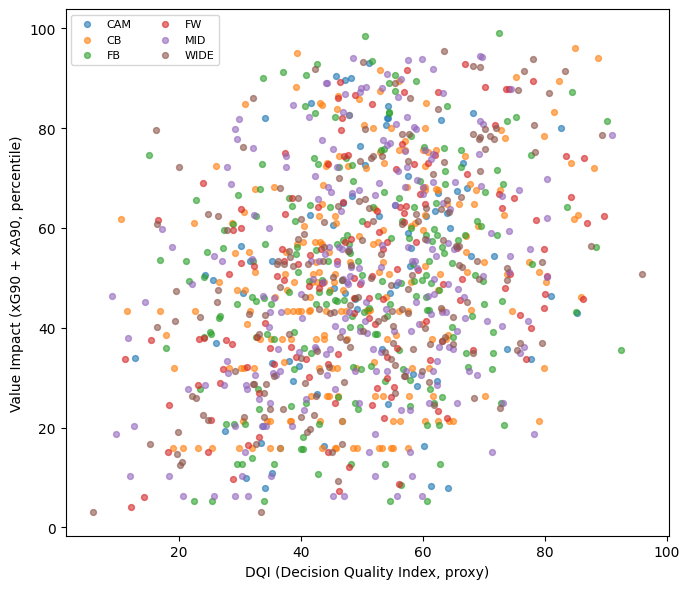

In [3]:
rho, p = spearmanr(out["DQI"], out["value_impact"])
print(f"Spearman rho (DQI vs Value Impact) = {rho:.3f}  (p = {p:.4f})")
print("Expected moderate correlation: an efficient player tends to also generate value,")
print("but the two dimensions are not identical — Value Impact remains a complementary")
print("metric rather than a redundant fifth axis on the radar.")

fig, ax = plt.subplots(figsize=(7, 6))
for role, sub in out.groupby("macro_pos"):
    ax.scatter(sub["DQI"], sub["value_impact"], s=18, alpha=0.6, label=role)
ax.set_xlabel("DQI (Decision Quality Index, proxy)")
ax.set_ylabel("Value Impact (xG90 + xA90, percentile)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## Section 3 — Profile Radar and Leaderboard

Highest DQI: Soren Sterling (Team 55, WIDE) — 95.9


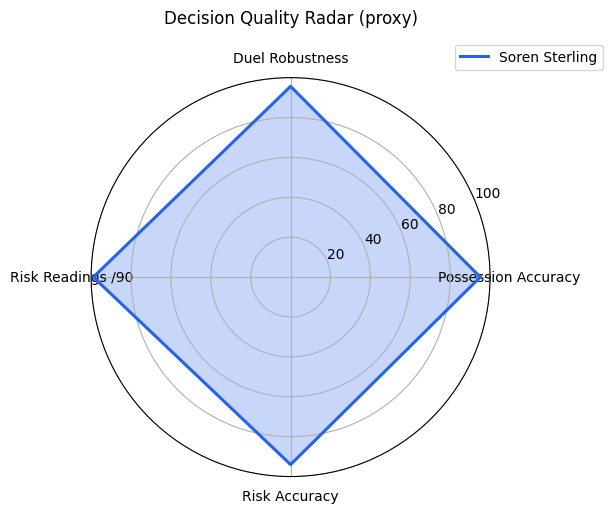

In [4]:
def build_dq_radar(rows: list[pd.Series], names: list[str], colors: list[str], height=6.5):
    labs = [DQ_LABEL_EN[k] for k in DQ_AXES]
    angles = np.linspace(0, 2 * np.pi, len(labs), endpoint=False).tolist()
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(height, height), subplot_kw=dict(polar=True))
    for row, name, color in zip(rows, names, colors):
        vals = [float(row[f"pct__{k}"]) for k in DQ_AXES]
        vals += vals[:1]
        ax.plot(angles, vals, color=color, linewidth=2.2, label=name)
        ax.fill(angles, vals, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(labs)
    ax.set_ylim(0, 100)
    ax.set_title("Decision Quality Radar (proxy)", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout(); plt.show()


leader = out.nlargest(1, "DQI").iloc[0]
print(f"Highest DQI: {leader["Player"]} ({leader["Team"]}, {leader['macro_pos']}) — {leader['DQI']:.1f}")
build_dq_radar([leader], [leader["Player"]], ["#2563eb"])

In [5]:
print("Top-20 Overall by DQI:")
top20 = out.nlargest(20, "DQI")[["Player", "Team", "macro_pos", "minutes", "DQI", "value_impact"]].round(1)
top20.columns = ["Player", "Team", "Role", "Min", "DQI", "Value Impact"]
top20.reset_index(drop=True)

Top-20 Overall by DQI:


,Player,Team,Role,Min,DQI,Value Impact
0,Soren Sterling,Team 55,WIDE,587,95.9,50.8
1,Dorian Hensley,Team 43,FB,421,92.6,35.6
2,Leo Hensley,Team 27,MID,1250,91.0,78.6
3,Lucas Pemberton,Team 33,FB,300,90.2,81.5
4,Quinn Montague,Team 26,FW,407,89.7,62.4
5,Xavier Blackwood,Team 27,WIDE,1416,89.4,78.7
6,Xavier Carrington,Team 34,CB,904,88.8,94.1
7,Noah Kingsbury,Team 45,FB,1644,88.5,56.2
8,Finn Vance,Team 27,CB,310,88.0,72.0
9,Alexander Vanderveer,Team 42,WIDE,330,87.6,56.4


### 3.1 — Top-5 within each macro role

In [6]:
for role in ROLE_ORDER:
    sub = out[out["macro_pos"] == role].nlargest(5, "DQI")
    if sub.empty:
        continue
    print(f"\n  {MACRO_LABEL_EN[role]} ({role})")
    display(sub[["Player", "Team", "DQI", "value_impact"]].rename(columns={"value_impact": "Value Impact"}).round(1).reset_index(drop=True))


  Center Back (CB)


,Player,Team,DQI,Value Impact
0,Xavier Carrington,Team 34,88.8,94.1
1,Finn Vance,Team 27,88.0,72.0
2,Finn Huntington,Team 20,85.9,46.2
3,Maxim Harrington,Team 6,85.5,62.7
4,Alastair Talbot,Team 2,85.0,96.1



  Full Back (FB)


,Player,Team,DQI,Value Impact
0,Dorian Hensley,Team 43,92.6,35.6
1,Lucas Pemberton,Team 33,90.2,81.5
2,Noah Kingsbury,Team 45,88.5,56.2
3,Noah Redmond,Team 30,85.2,43.2
4,Tristan Ravensdale,Team 34,84.6,87.3



  Midfielder (MID)


...

,Player,Team,DQI,Value Impact
0,Dominic Lansbury,Team 31,85.3,43.0
1,Arthur Zimmerman,Team 29,82.7,80.0
2,Sebastian Kingsbury,Team 50,81.0,46.3
3,Emil Lansbury,Team 29,77.8,33.7
4,Hugo Mercer,Team 34,73.8,35.7



  Winger (WIDE)


,Player,Team,DQI,Value Impact
0,Soren Sterling,Team 55,95.9,50.8
1,Xavier Blackwood,Team 27,89.4,78.7
2,Alexander Vanderveer,Team 42,87.6,56.4
3,Tobias Norwood,Team 31,83.3,91.5
4,Tobias Prescott,Team 49,80.7,87.0



  Forward (FW)


,Player,Team,DQI,Value Impact
0,Quinn Montague,Team 26,89.7,62.4
1,Florian Mercer,Team 34,87.0,61.0
2,Nikolai Thornton,Team 36,86.5,74.0
3,Emil Drayton,Team 12,86.3,45.7
4,Caleb Fenwick,Team 50,84.3,66.2


### 3.2 — Direct comparison: most efficient vs. most impactful

Just as the original compares decision efficiency with value generation (ρ ≈ 0.76 in the source notebook, correlated but not identical), here we compare the DQI leader with the Value Impact leader — if they are different players, it visually confirms that both axes capture distinct dimensions.

DQI Leader          : Soren Sterling (Team 55) — DQI 96, Impact 51
Value Impact Leader : Dominic Winterbottom (Team 55) — DQI 73, Impact 99


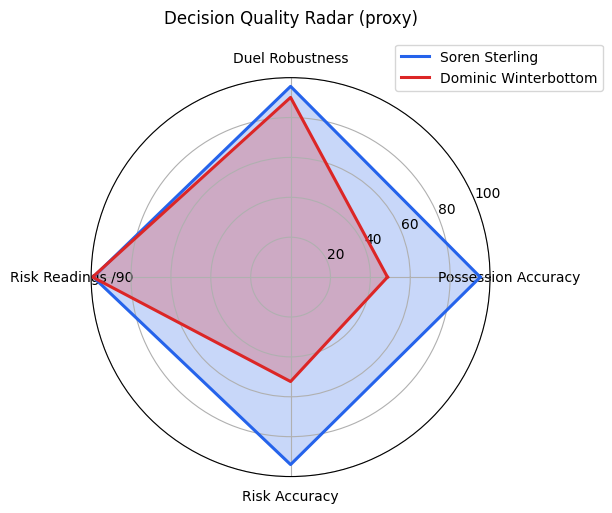

In [7]:
iqd_leader = out.nlargest(1, "DQI").iloc[0]
value_leader = out.nlargest(1, "value_impact").iloc[0]
p_iqd_name = iqd_leader["Player"]
p_iqd_team = iqd_leader["Team"]
p_val_name = value_leader["Player"]
p_val_team = value_leader["Team"]
print(f"DQI Leader          : {p_iqd_name} ({p_iqd_team}, {iqd_leader['macro_pos']}) - DQI {iqd_leader['DQI']:.1f}")
print(f"Value Impact Leader : {p_val_name} ({p_val_team}, {value_leader['macro_pos']}) - Value Impact {value_leader['value_impact']:.1f}")


## Conclusion

- **This is a proxy index.** It measures seasonal technical efficiency and execution — possession accuracy, duel robustness, volume of incisive actions, and accuracy on progressive passes. The original metric measures something structurally different: whether the player chose the optimal option among all candidates visible in the freeze frame. Without event-level tracking data, that question cannot be answered from aggregate tables.
- **DQI correlates with Value Impact without duplicating it** (Section 2) — mirroring the qualitative pattern of the original model (DQ correlated but not identical to Value Impact), confirming that efficiency and creation separate distinct player profiles.
- **Recommended usage**: as a complementary measure of "who executes reliably what they attempt" within their role — rather than an optical tracking substitute.